# Breast Cancer Wisconsin (Diagnostic)

Target: Predict whether the cancer is benign or malignant

Source: https://www.kaggle.com/uciml/breast-cancer-wisconsin-data

In this notebook, I will touch medicine in practice. I analyze breast cancer Wisconsin. It is a diagnostic data set.
I studied computer science in medicine, so now I would like to combine medical knowledge with machine learning.

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. Fine-needle aspiration (FNA) is a diagnostic procedure used to investigate lumps or masses. In this technique, a thin (23–25 gauge), hollow needle is inserted into the mass for sampling of cells that, after being stained, will be examined under a microscope (biopsy).

https://en.wikipedia.org/wiki/Fine-needle_aspiration

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn import linear_model
from sklearn.naive_bayes import GaussianNB

In [2]:
df = pd.read_csv('input/data.csv')
df.sample(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
317,894326,M,18.22,18.87,118.70,1027.0,0.09746,0.11170,0.11300,0.07950,0.1807,0.05664,0.4041,0.5503,2.547,48.90,0.004821,0.016590,0.024080,0.011430,0.01275,0.002451,21.84,25.00,140.90,1485.0,0.1434,0.2763,0.3853,0.17760,0.2812,0.08198,NaN
330,896839,M,16.03,15.51,105.80,793.2,0.09491,0.13710,0.12040,0.07041,0.1782,0.05976,0.3371,0.7476,2.629,33.27,0.005839,0.032450,0.037150,0.014590,0.01467,0.003121,18.76,21.98,124.30,1070.0,0.1435,0.4478,0.4956,0.19810,0.3019,0.09124,NaN
113,864292,B,10.51,20.19,68.64,334.2,0.11220,0.13030,0.06476,0.03068,0.1922,0.07782,0.3336,1.8600,2.041,19.91,0.011880,0.037470,0.045910,0.015440,0.02287,0.006792,11.16,22.75,72.62,374.4,0.1300,0.2049,0.1295,0.06136,0.2383,0.09026,NaN
439,909410,B,14.02,15.66,89.59,606.5,0.07966,0.05581,0.02087,0.02652,0.1589,0.05586,0.2142,0.6549,1.606,19.25,0.004837,0.009238,0.009213,0.010760,0.01171,0.002104,14.91,19.31,96.53,688.9,0.1034,0.1017,0.0626,0.08216,0.2136,0.06710,NaN
26,852763,M,14.58,21.53,97.41,644.8,0.10540,0.18680,0.14250,0.08783,0.2252,0.06924,0.2545,0.9832,2.110,21.05,0.004452,0.030550,0.026810,0.013520,0.01454,0.003711,17.62,33.21,122.40,896.9,0.1525,0.6643,0.5539,0.27010,0.4264,0.12750,NaN
339,89812,M,23.51,24.27,155.10,1747.0,0.10690,0.12830,0.23080,0.14100,0.1797,0.05506,1.0090,0.9245,6.462,164.10,0.006292,0.019710,0.035820,0.013010,0.01479,0.003118,30.67,30.73,202.40,2906.0,0.1515,0.2678,0.4819,0.20890,0.2593,0.07738,NaN
533,91930402,M,20.47,20.67,134.70,1299.0,0.09156,0.13130,0.15230,0.10150,0.2166,0.05419,0.8336,1.7360,5.168,100.40,0.004938,0.030890,0.040930,0.016990,0.02816,0.002719,23.23,27.15,152.00,1645.0,0.1097,0.2534,0.3092,0.16130,0.3220,0.06386,NaN
224,8813129,B,13.27,17.02,84.55,546.4,0.08445,0.04994,0.03554,0.02456,0.1496,0.05674,0.2927,0.8907,2.044,24.68,0.006032,0.011040,0.022590,0.009057,0.01482,0.002496,15.14,23.60,98.84,708.8,0.1276,0.1311,0.1786,0.09678,0.2506,0.07623,NaN
120,865137,B,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,0.1408,0.4607,1.103,10.50,0.006040,0.015290,0.015140,0.006460,0.01344,0.002206,12.82,15.97,83.74,510.5,0.1548,0.2390,0.2102,0.08958,0.3016,0.08523,NaN
257,886776,M,15.32,17.27,103.20,713.3,0.13350,0.22840,0.24480,0.12420,0.2398,0.07596,0.6592,1.0590,4.061,59.46,0.010150,0.045880,0.049830,0.021270,0.01884,0.008660,17.73,22.66,119.80,928.8,0.1765,0.4503,0.4429,0.22290,0.3258,0.11910,NaN


### Basic intro

In [3]:
print(df.diagnosis.nunique())
df.diagnosis.unique()

2


array(['M', 'B'], dtype=object)

In [4]:
df['diagnosis_cat'] = pd.factorize(df['diagnosis'])[0]

In [5]:
df.shape

(569, 34)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 34 columns):
id                         569 non-null int64
diagnosis                  569 non-null object
radius_mean                569 non-null float64
texture_mean               569 non-null float64
perimeter_mean             569 non-null float64
area_mean                  569 non-null float64
smoothness_mean            569 non-null float64
compactness_mean           569 non-null float64
concavity_mean             569 non-null float64
concave points_mean        569 non-null float64
symmetry_mean              569 non-null float64
fractal_dimension_mean     569 non-null float64
radius_se                  569 non-null float64
texture_se                 569 non-null float64
perimeter_se               569 non-null float64
area_se                    569 non-null float64
smoothness_se              569 non-null float64
compactness_se             569 non-null float64
concavity_se               569 non

In [7]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32',
       'diagnosis_cat'],
      dtype='object')

In [8]:
df.isnull().any()

id                         False
diagnosis                  False
radius_mean                False
texture_mean               False
perimeter_mean             False
area_mean                  False
smoothness_mean            False
compactness_mean           False
concavity_mean             False
concave points_mean        False
symmetry_mean              False
fractal_dimension_mean     False
radius_se                  False
texture_se                 False
perimeter_se               False
area_se                    False
smoothness_se              False
compactness_se             False
concavity_se               False
concave points_se          False
symmetry_se                False
fractal_dimension_se       False
radius_worst               False
texture_worst              False
perimeter_worst            False
area_worst                 False
smoothness_worst           False
compactness_worst          False
concavity_worst            False
concave points_worst       False
symmetry_w

In [9]:
df = df.drop(['id', 'Unnamed: 32'], 1)

In [10]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_cat
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Visualisations

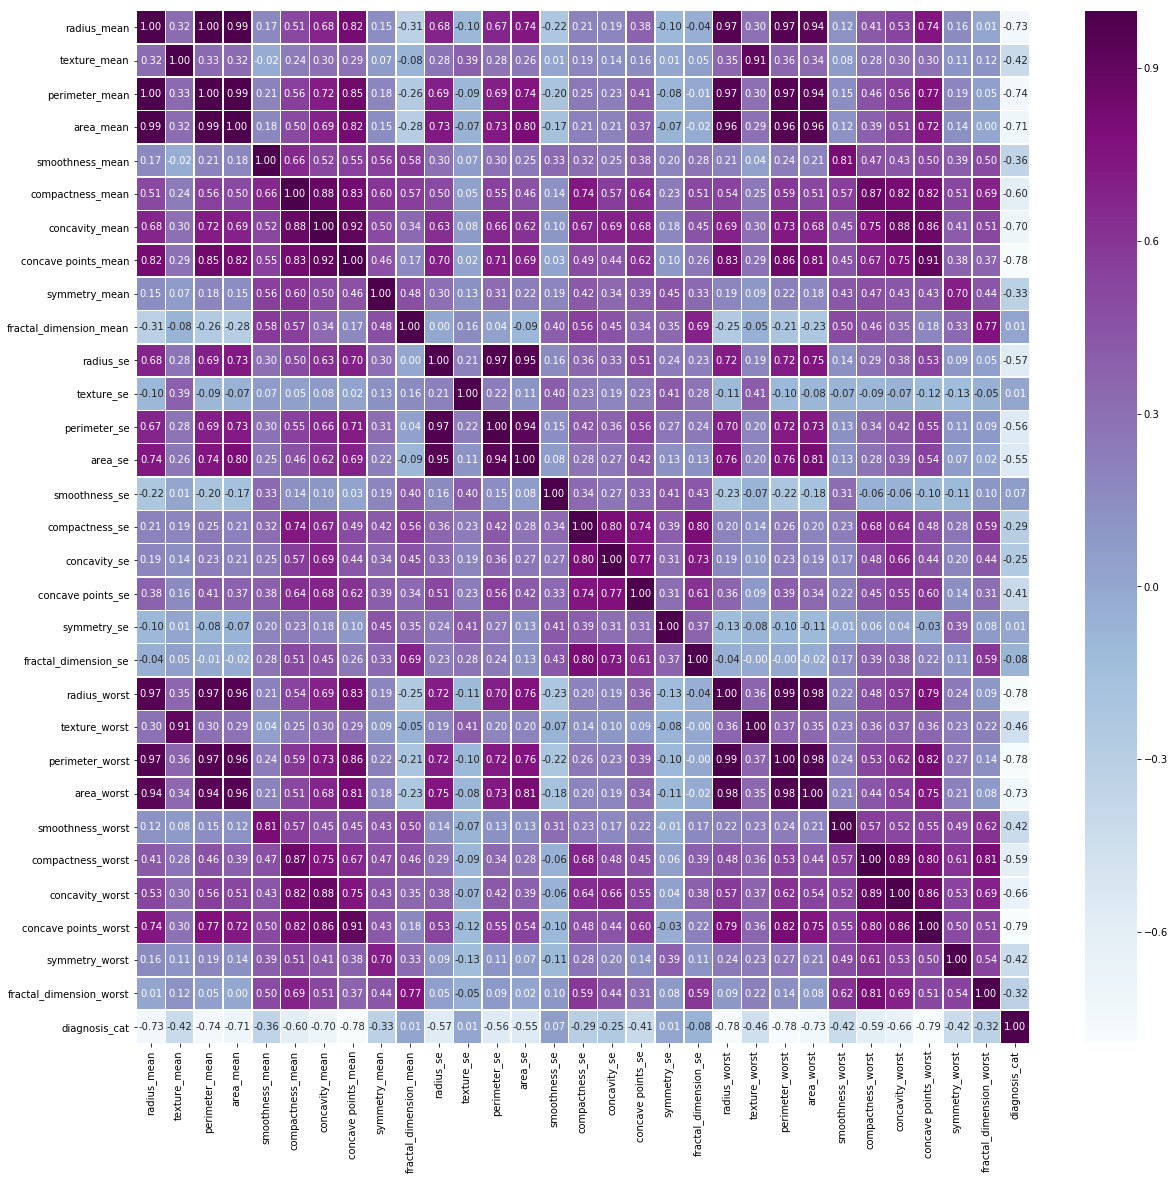

In [11]:
plt.rcParams['figure.figsize']=(20,19)
sns.heatmap(df.corr(), annot=True, linewidths=.5, fmt = ".2f", cmap="BuPu");

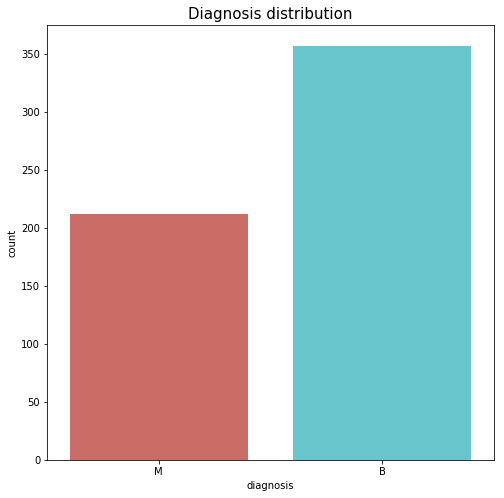

In [12]:
plt.rcParams['figure.figsize']=(8,8)
ax = sns.countplot(x = 'diagnosis', data = df, palette = 'hls');
ax.set_title(label='Diagnosis distribution', fontsize=15);

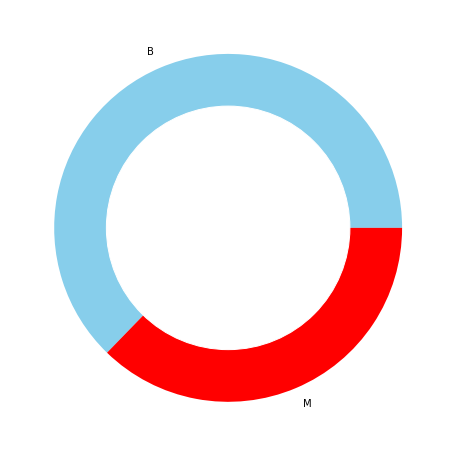

In [13]:
names= 'B', 'M'
size=df['diagnosis'].value_counts()

my_circle=plt.Circle((0,0), 0.7, color='white')

plt.pie(size, labels=names, colors=['skyblue','red'])
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.show()

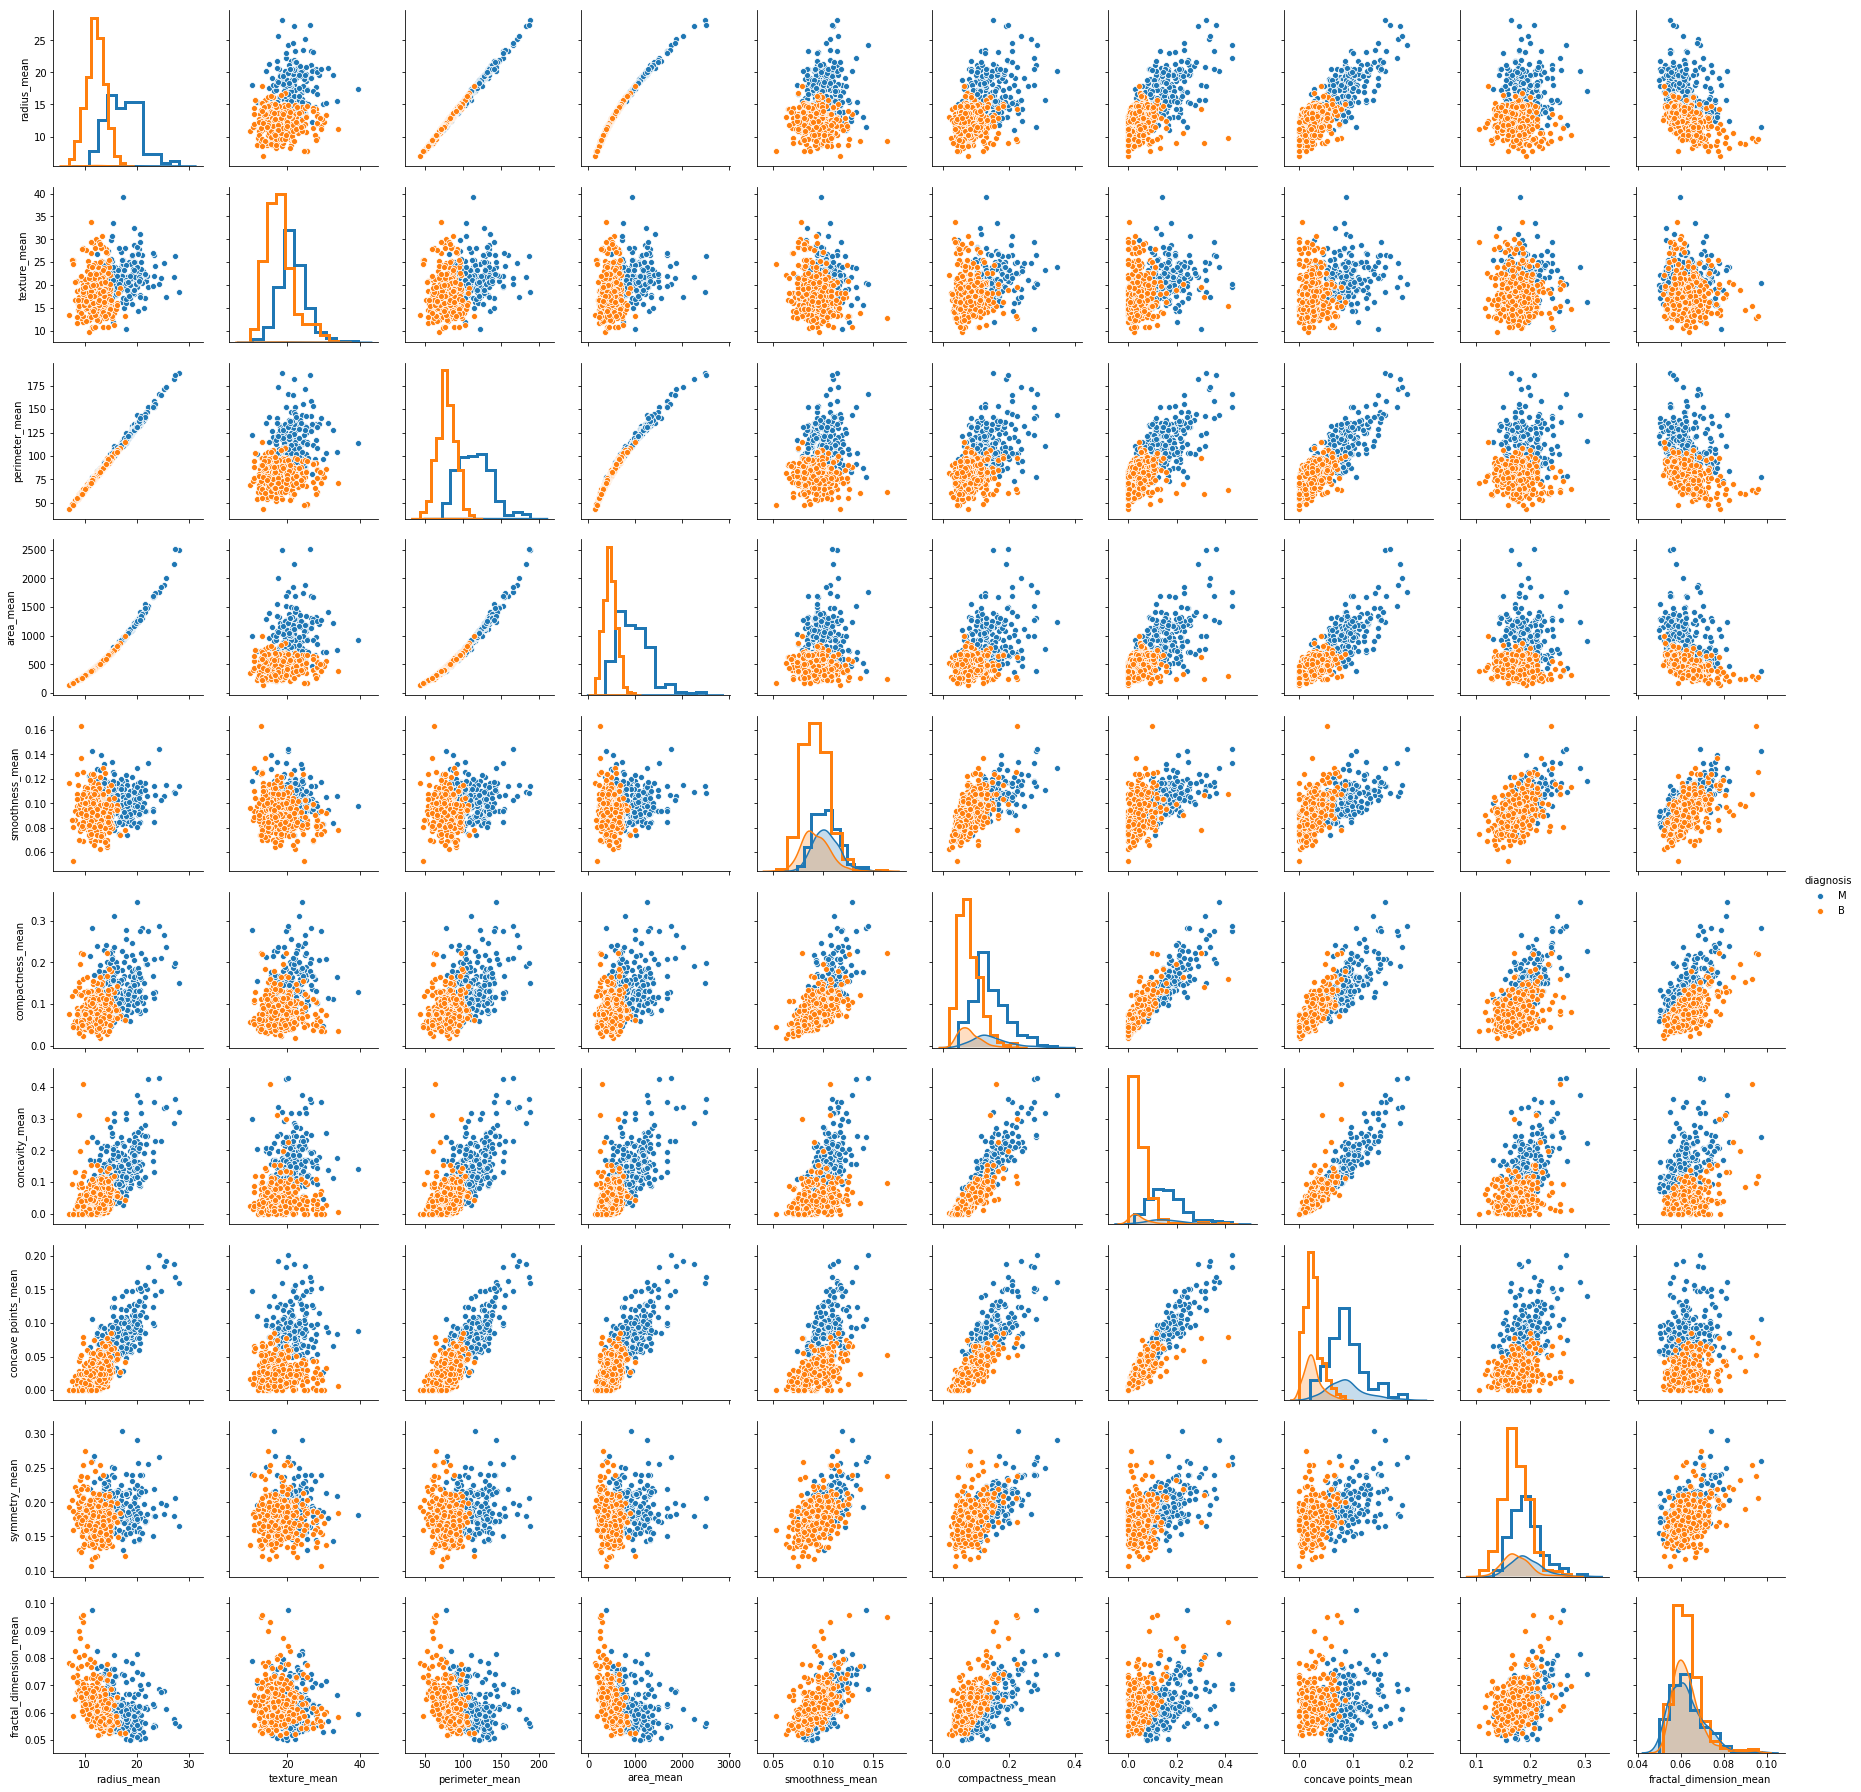

In [14]:
g = sns.pairplot(df.iloc[:,0:11], hue = 'diagnosis');
g = g.map_diag(plt.hist, histtype="step", linewidth=3)

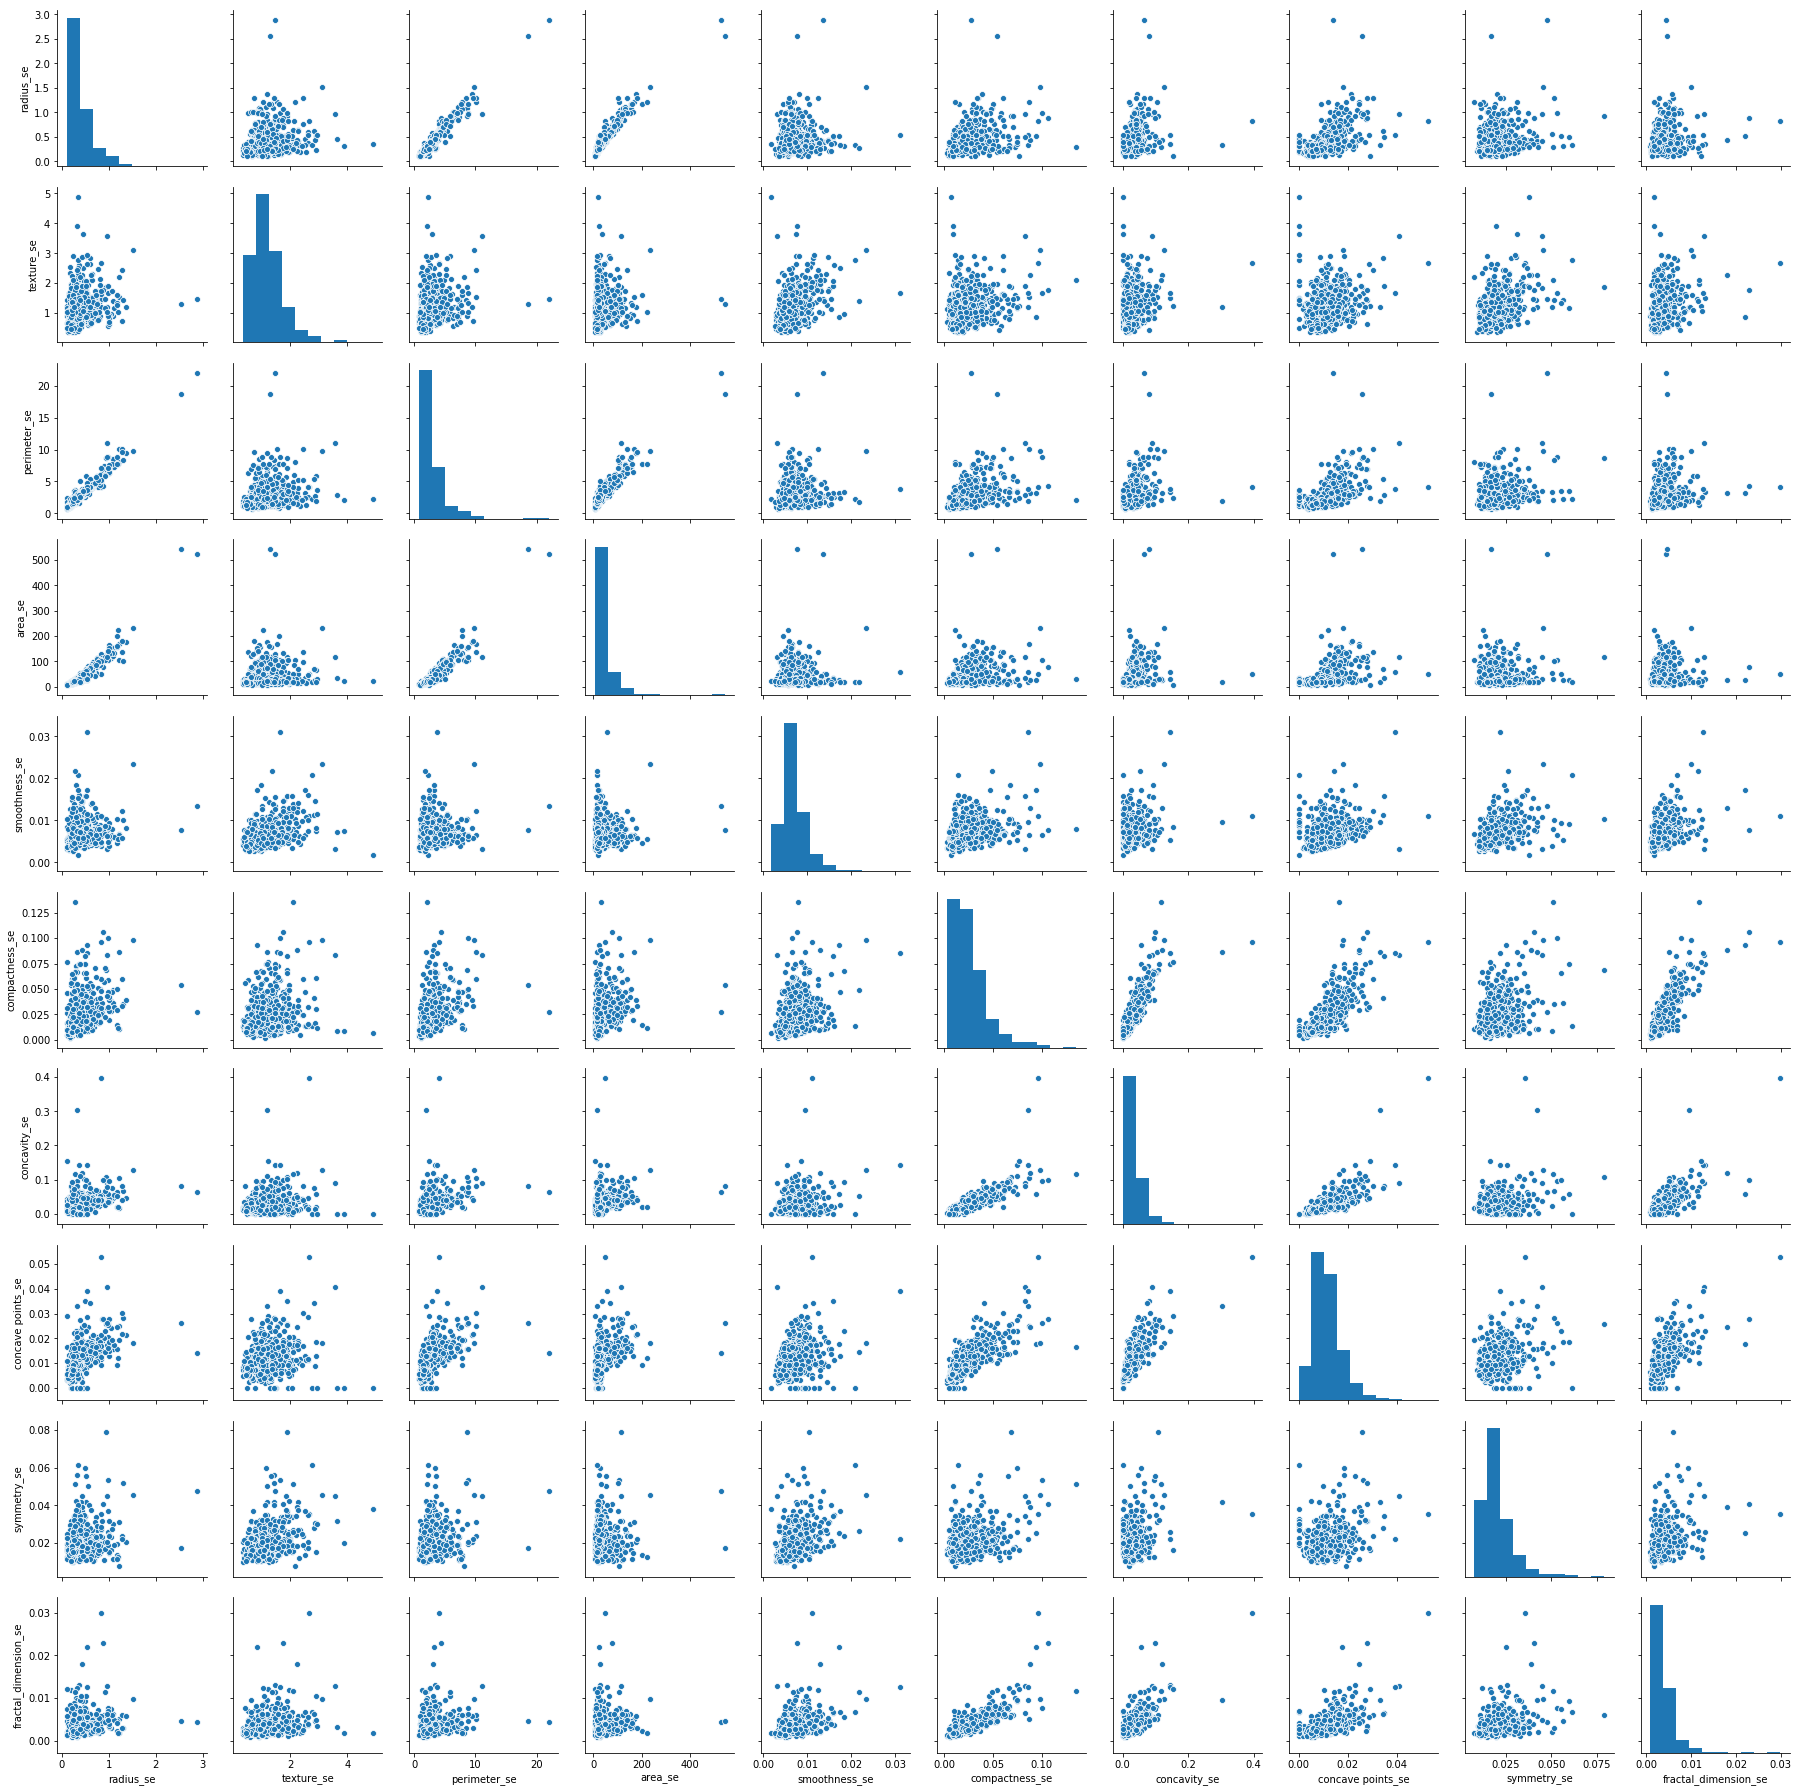

In [15]:
sns.pairplot(df.iloc[:,11:21]);

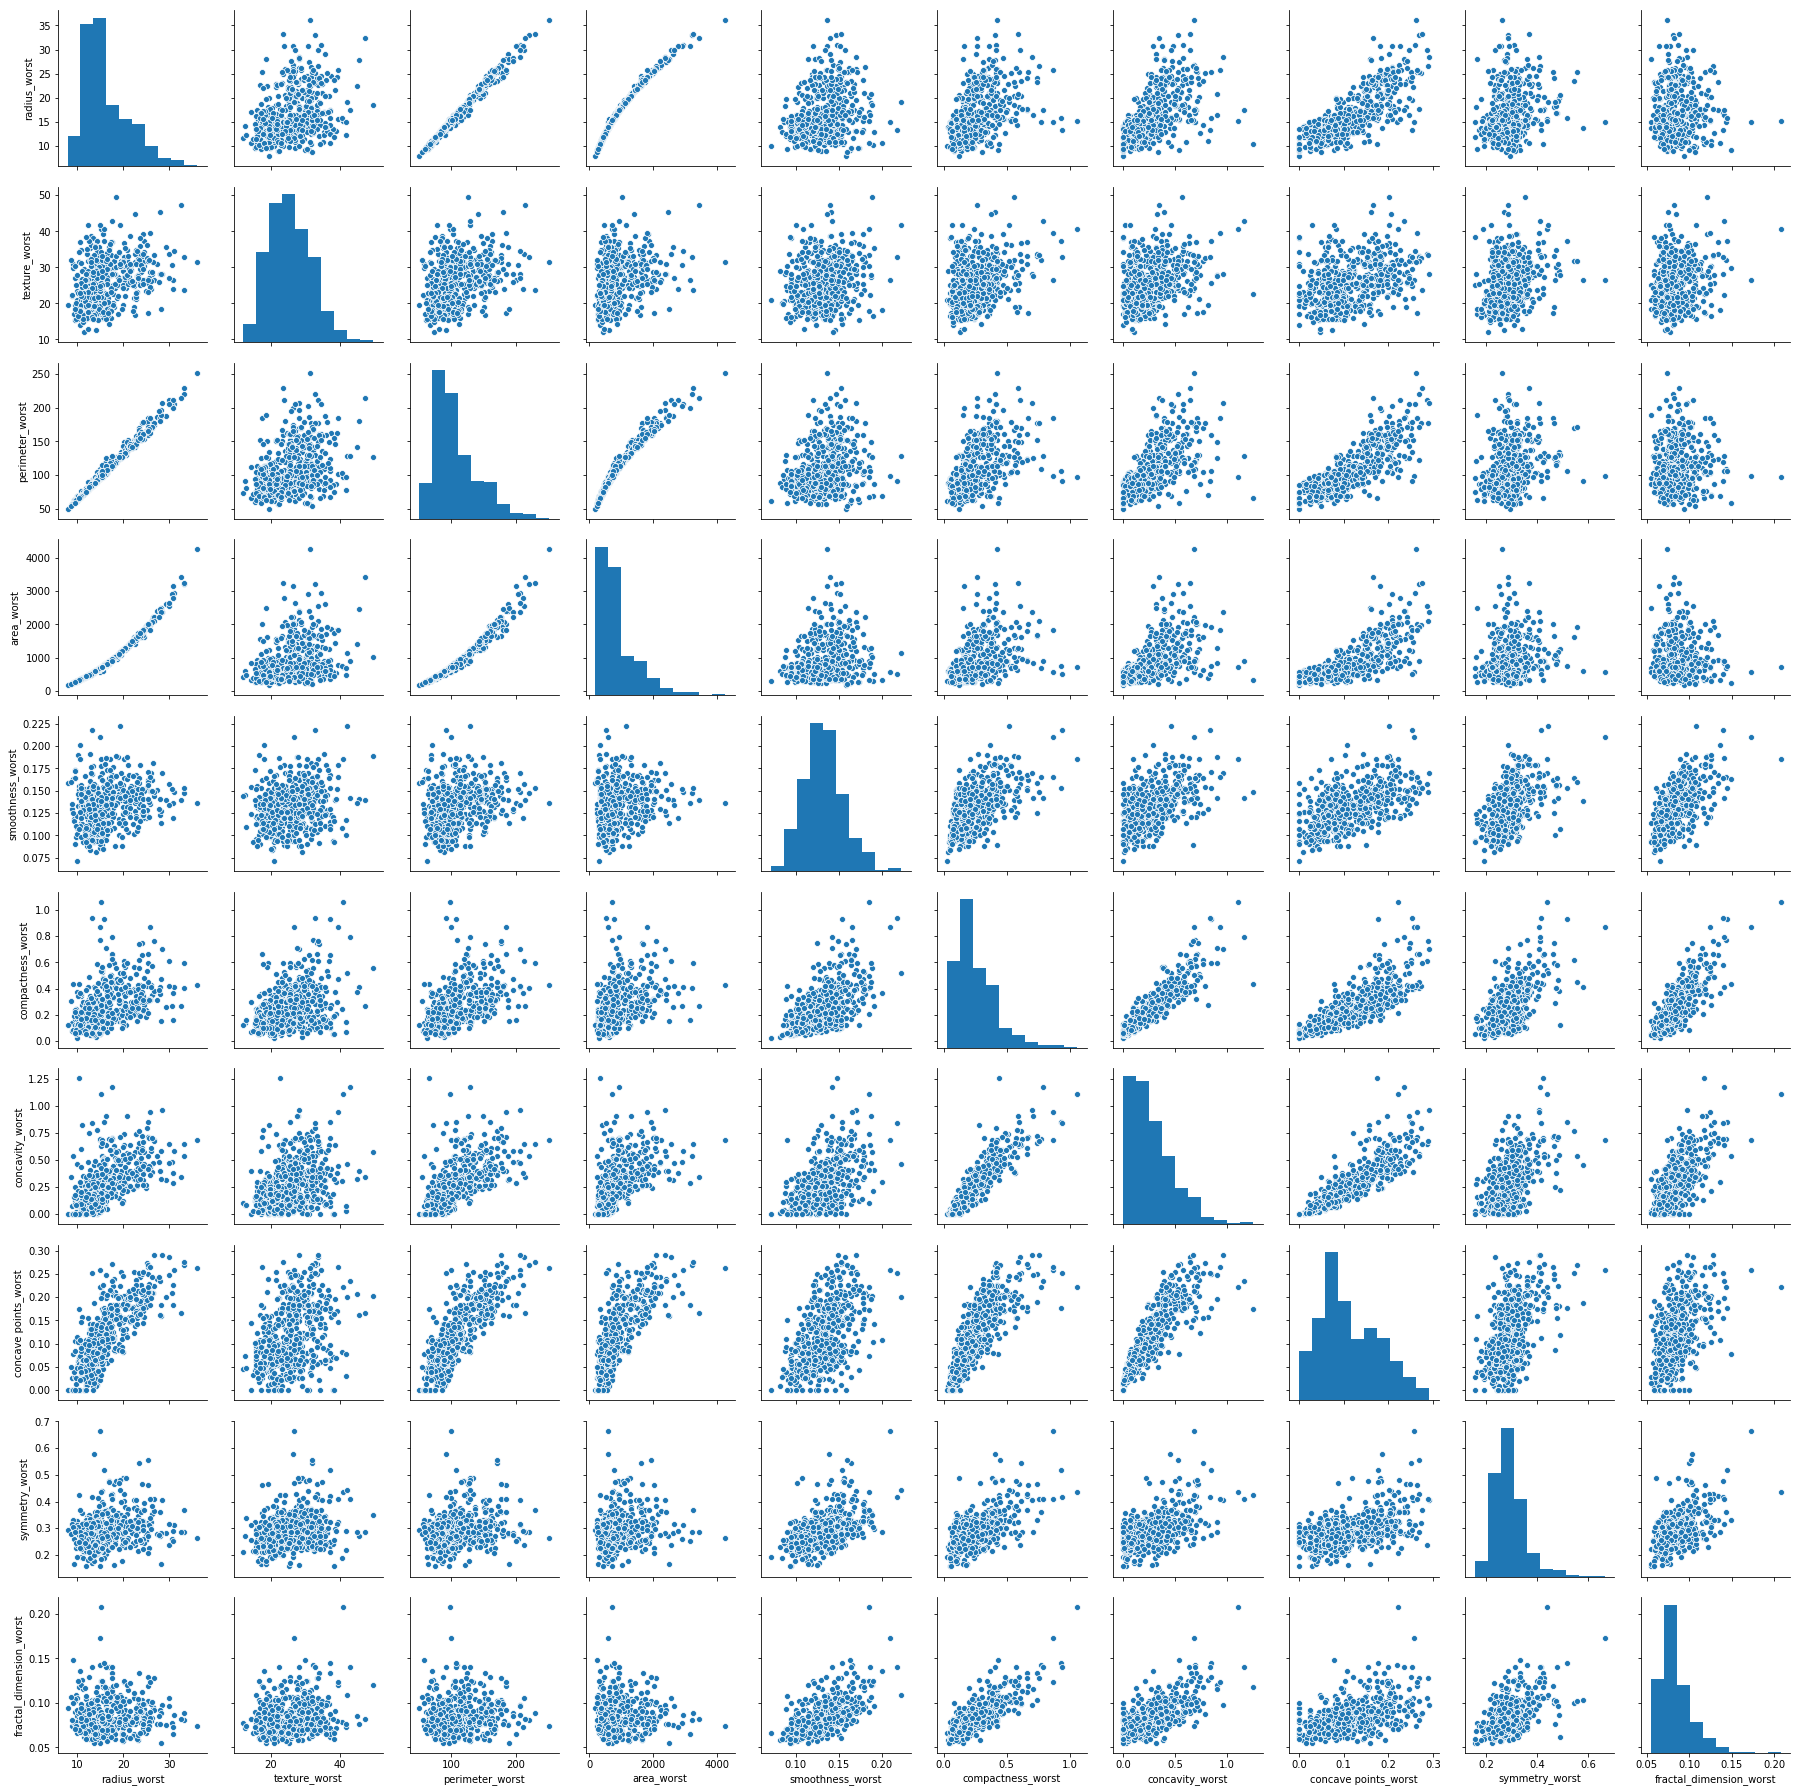

In [16]:
sns.pairplot(df.iloc[:,21:31]);

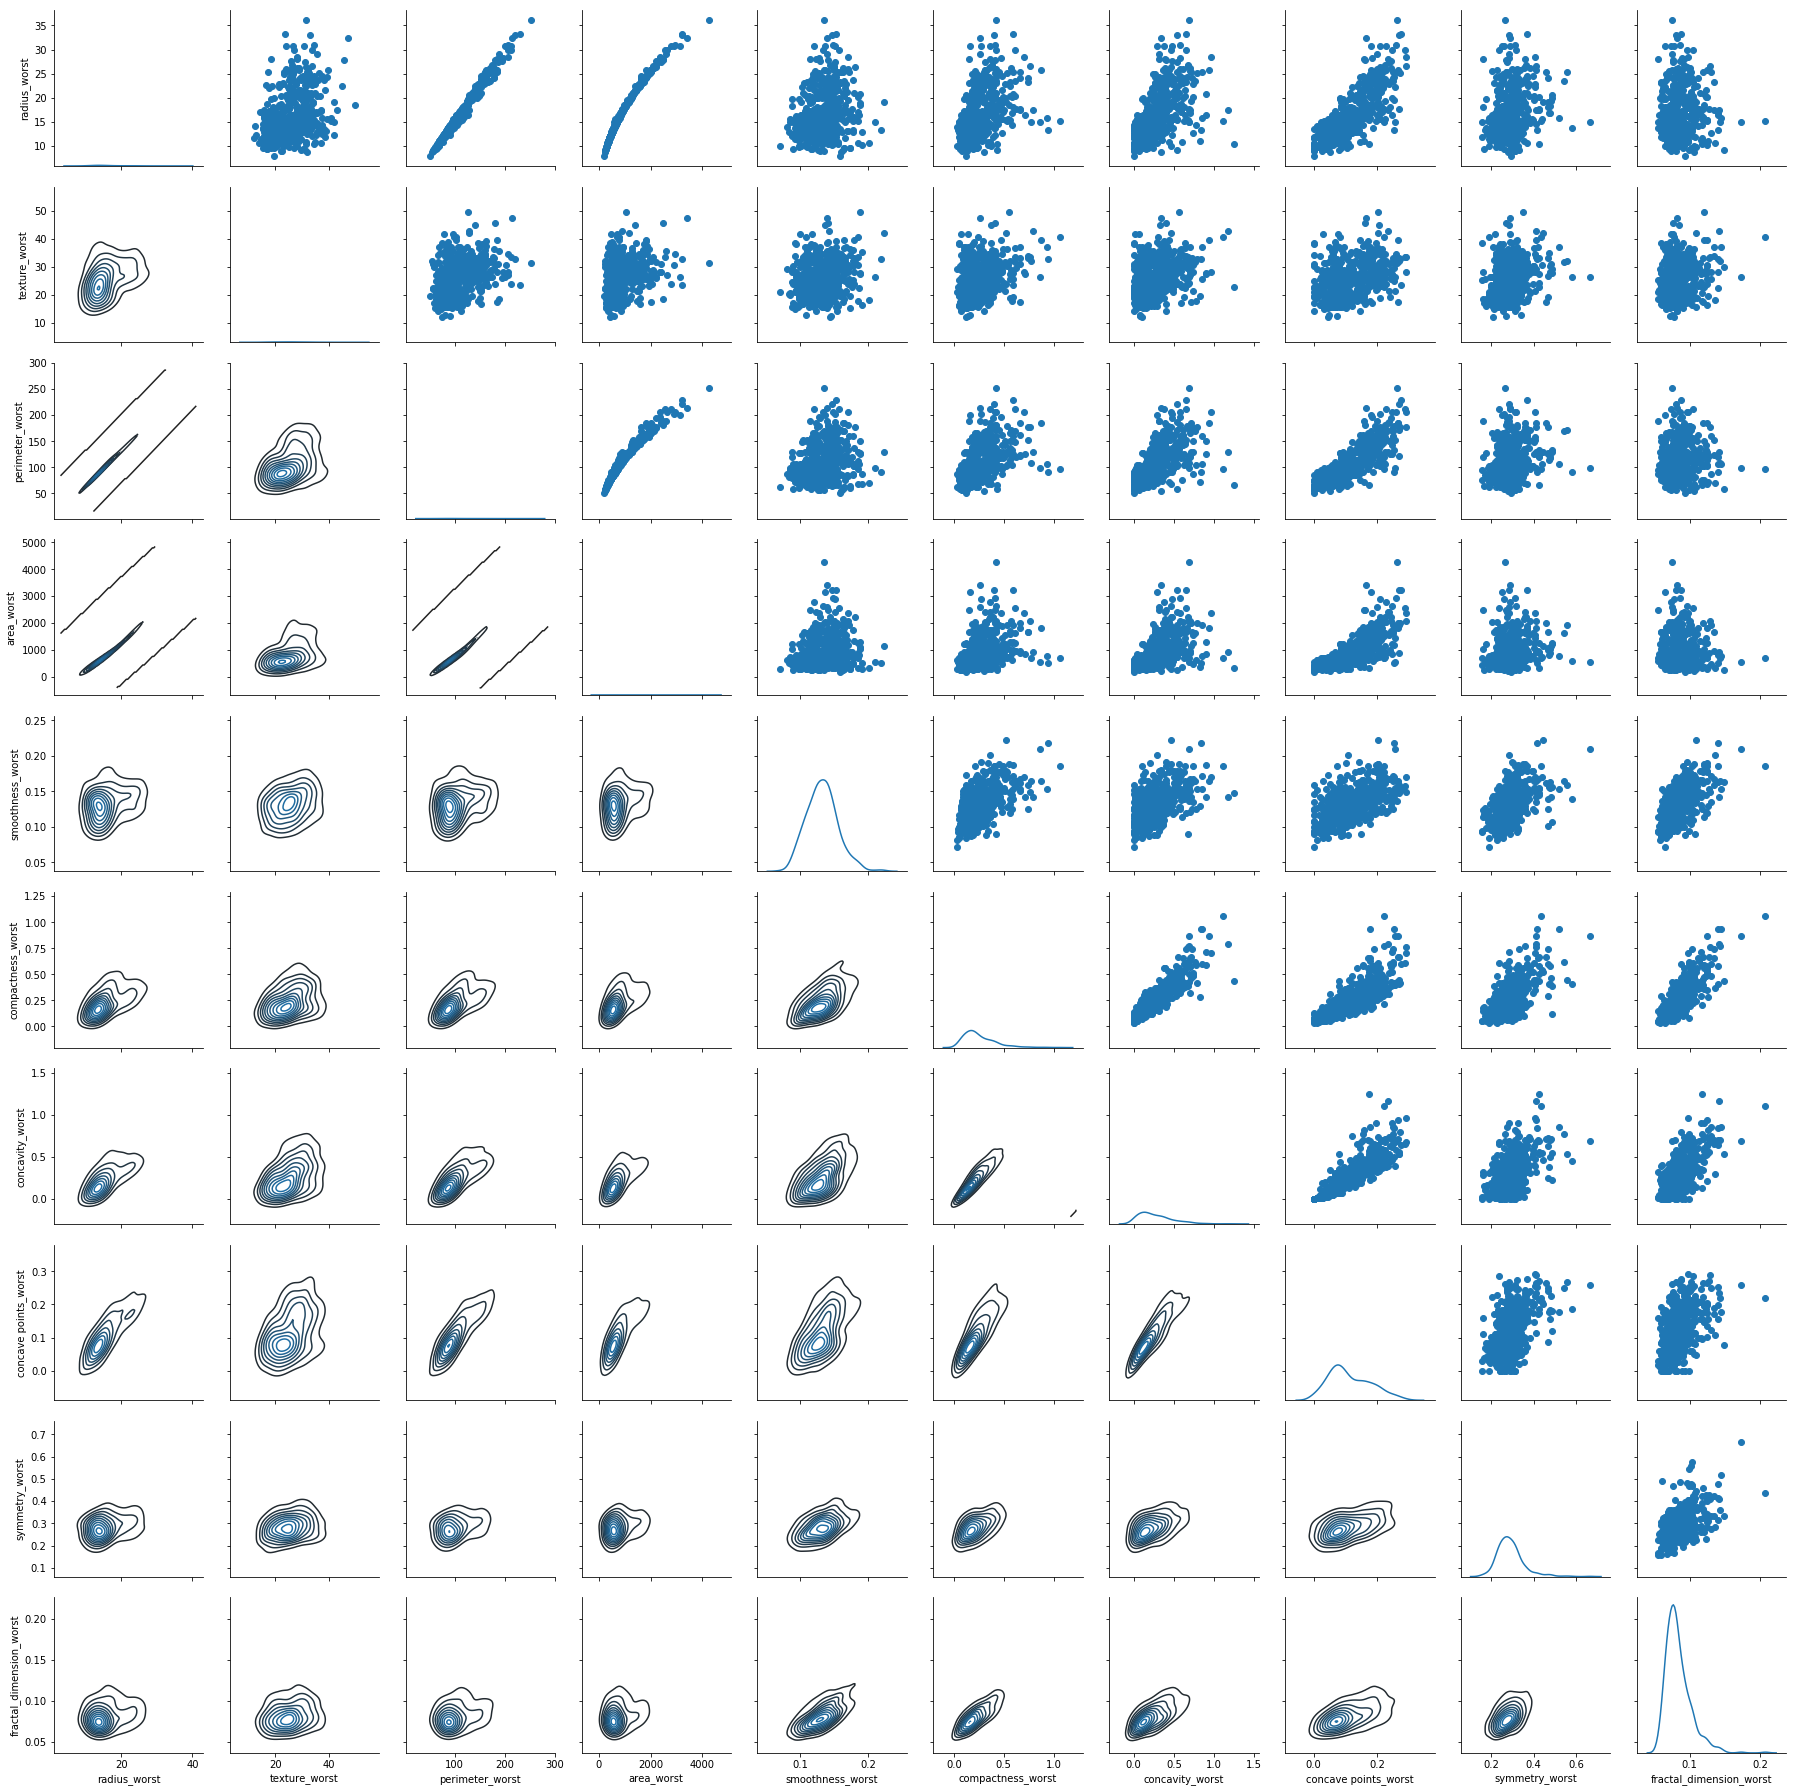

In [17]:
v = sns.PairGrid(df.iloc[:,21:31])
v.map_lower(sns.kdeplot);
v.map_upper(plt.scatter);
v.map_diag(sns.kdeplot);

In [18]:
def feats(df):
    feats_from_df = set(df.select_dtypes([np.int, np.float]).columns.values)
    bad_feats = {'diagnosis_cat'}
    return list(feats_from_df - bad_feats)

df_scaled = df
df_scaled[feats(df)] = preprocessing.scale(df[feats(df)])

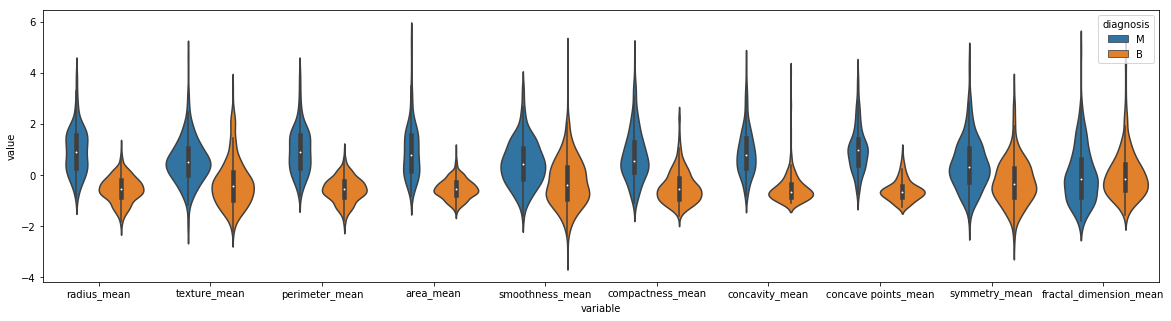

In [19]:
plt.subplots(figsize=(20,5))
df_melted = pd.melt(df_scaled, id_vars = "diagnosis", 
                      value_vars = ('radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                                    'smoothness_mean', 'compactness_mean', 'concavity_mean',
                                    'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean'))
sns.violinplot(x = "variable", y = "value", hue="diagnosis",data= df_melted);

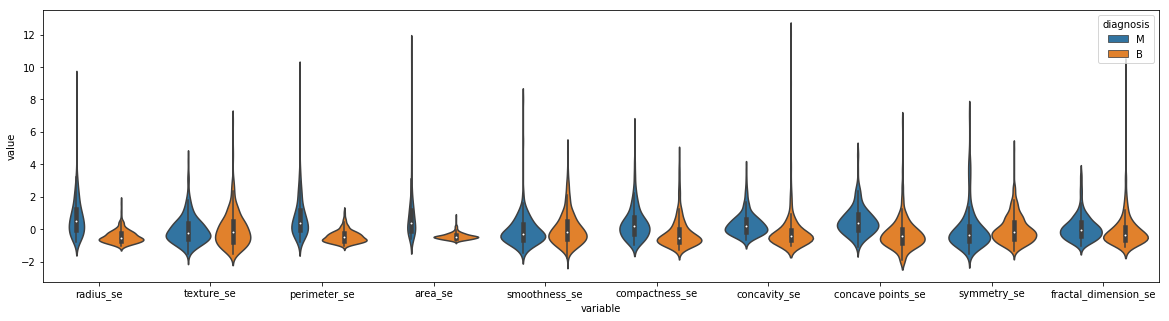

In [20]:
plt.subplots(figsize=(20,5))
df_melted = pd.melt(df_scaled, id_vars = "diagnosis", 
                      value_vars = ('radius_se', 'texture_se', 'perimeter_se', 'area_se',
                                    'smoothness_se', 'compactness_se', 'concavity_se',
                                    'concave points_se', 'symmetry_se', 'fractal_dimension_se'))
sns.violinplot(x = "variable", y = "value", hue="diagnosis",data= df_melted);

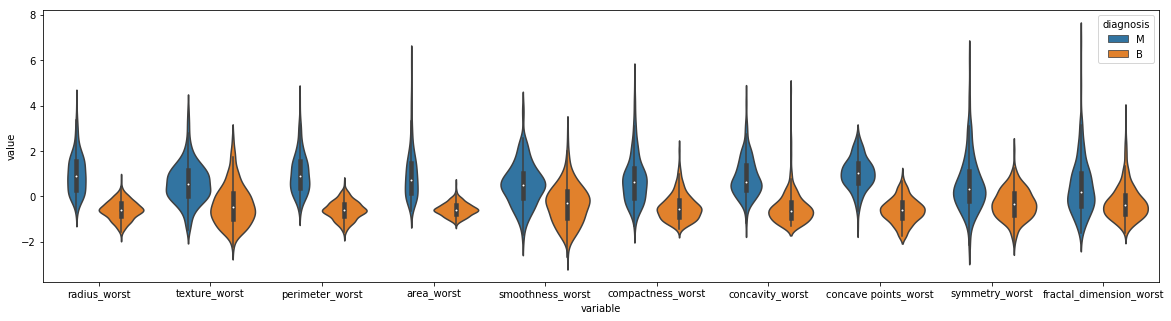

In [21]:
plt.subplots(figsize=(20,5))
df_melted = pd.melt(df_scaled, id_vars = "diagnosis", 
                      value_vars = ('radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
                                    'smoothness_worst', 'compactness_worst', 'concavity_worst',
                                    'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'))
sns.violinplot(x = "variable", y = "value", hue="diagnosis",data= df_melted);

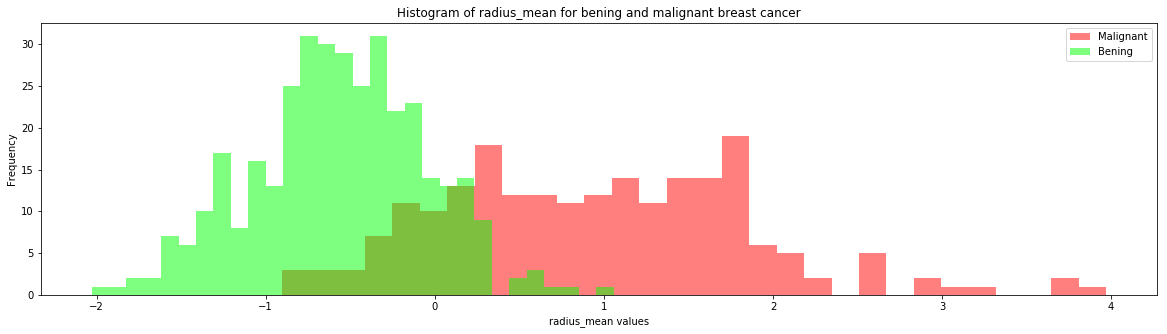

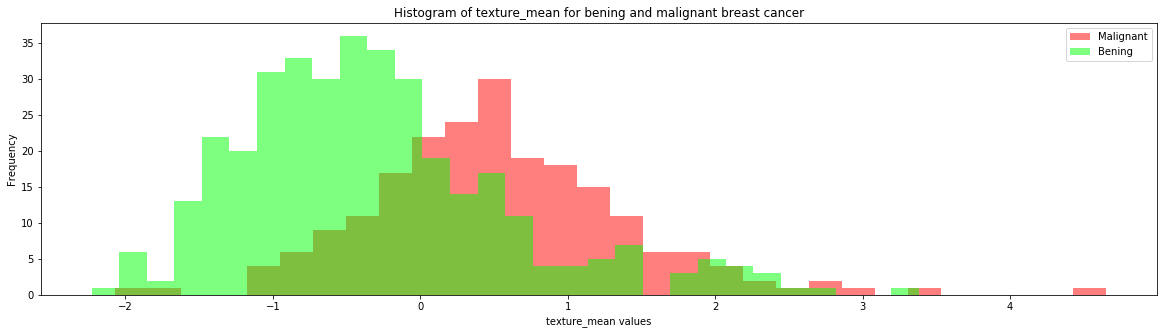

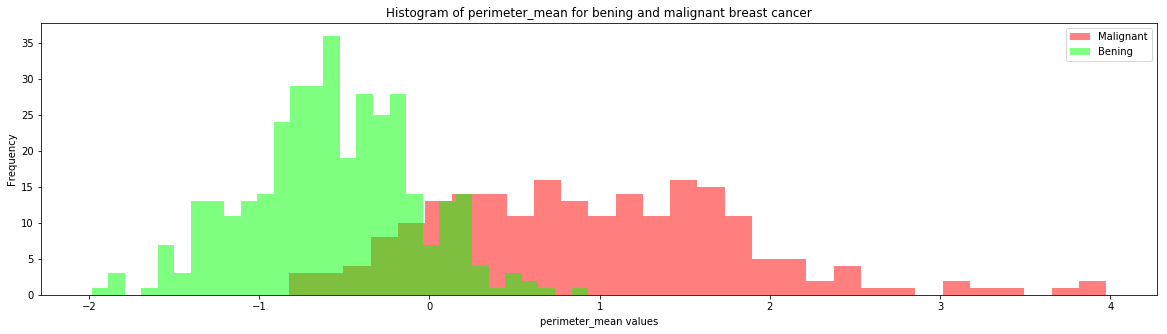

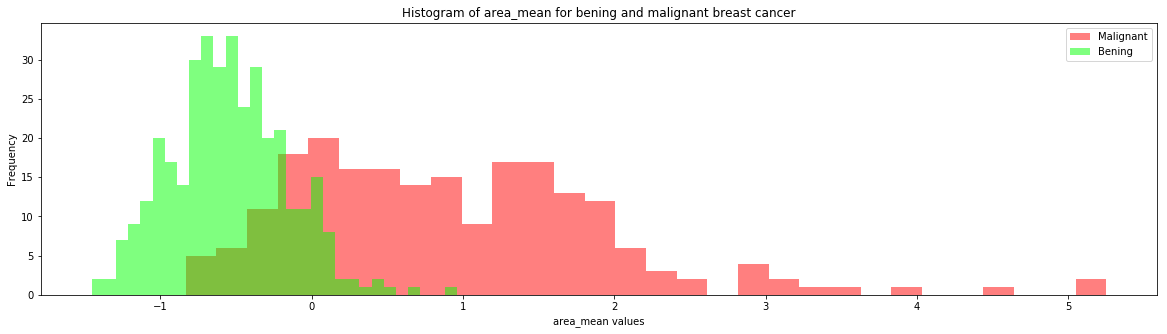

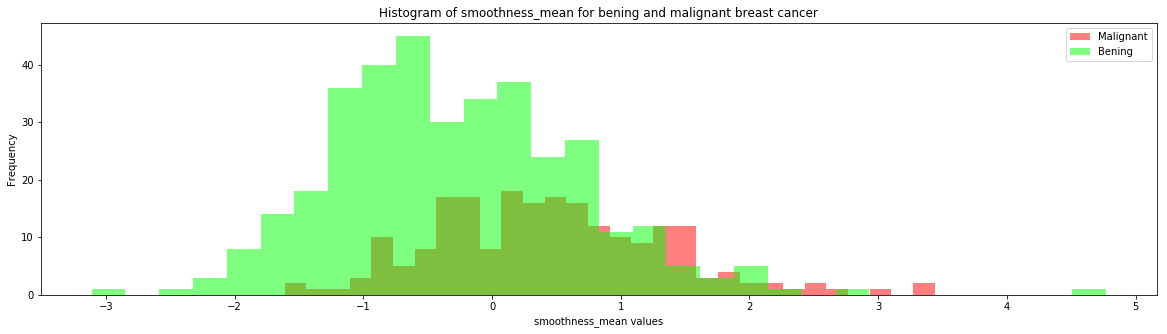

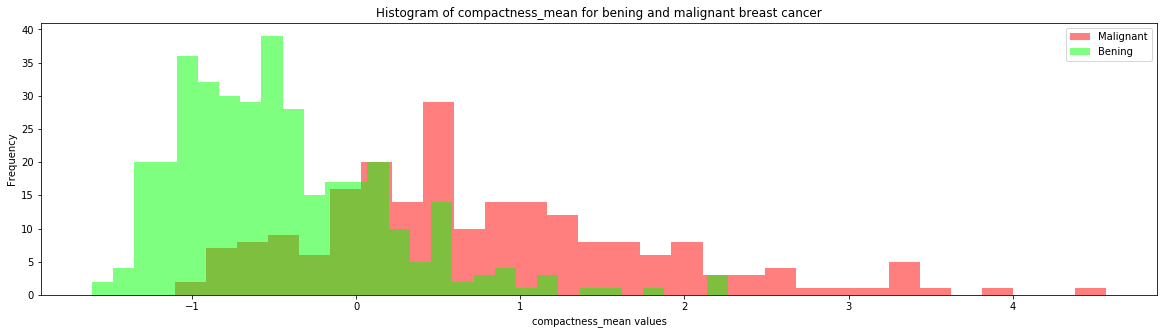

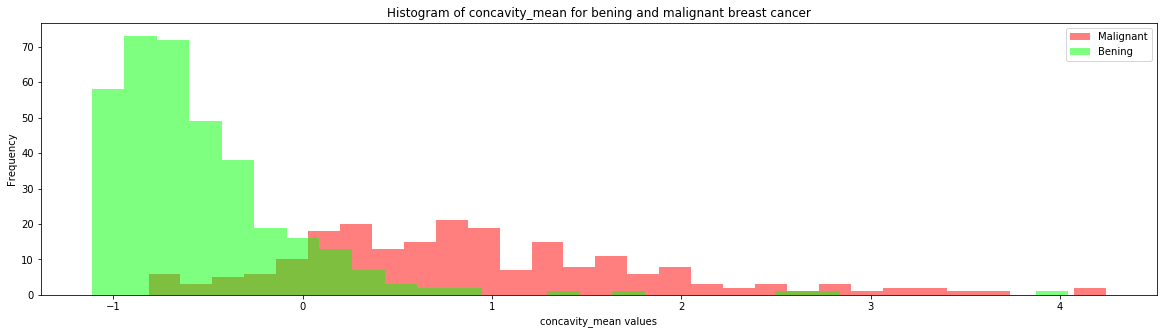

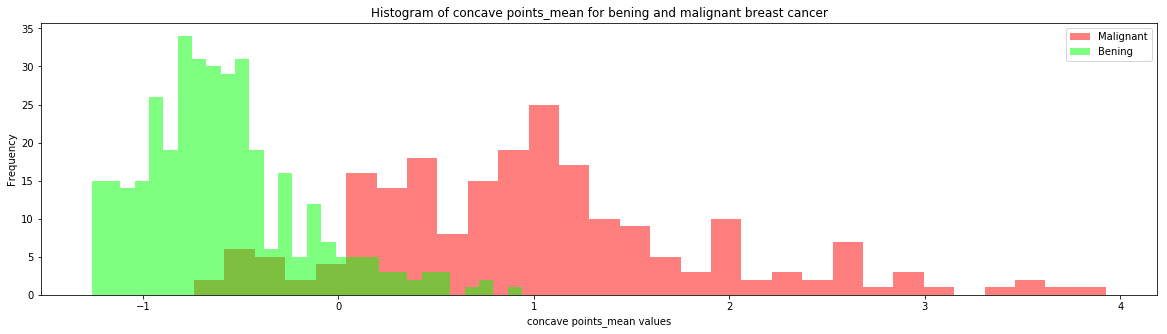

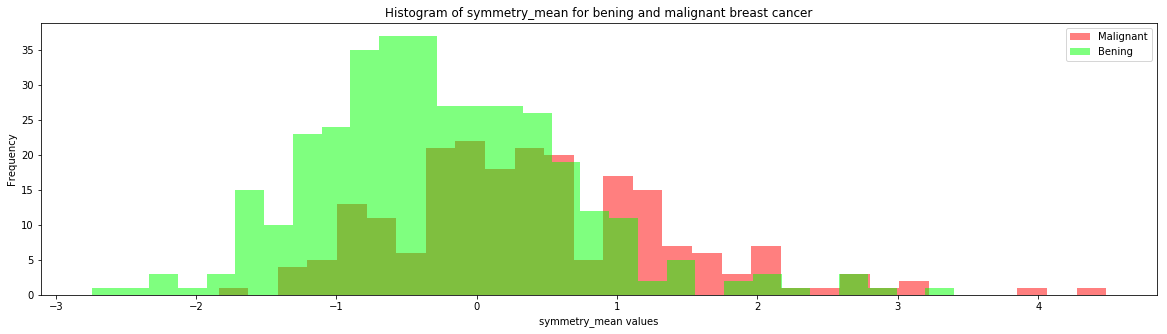

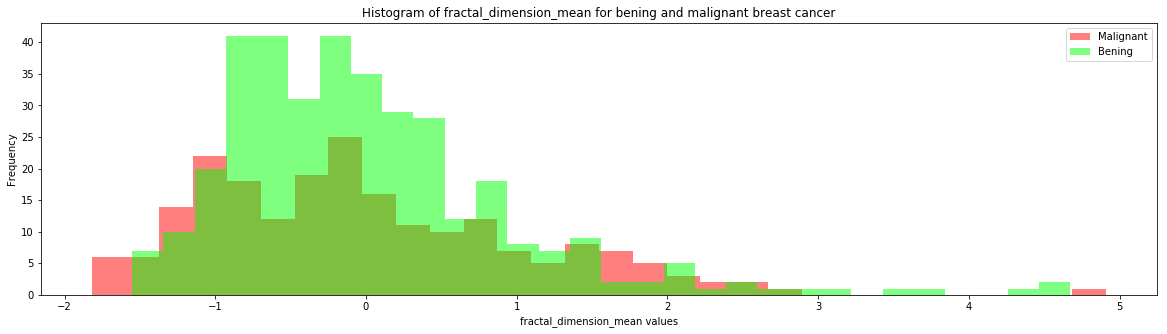

In [22]:
plt.rcParams['figure.figsize']=(20,5)

mean_value = ('radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
              'smoothness_mean', 'compactness_mean', 'concavity_mean',
               'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean')

for i, feat in enumerate(mean_value):
    m = plt.hist(df[df["diagnosis"] == "M"][feat],bins=30,fc = (1,0,0,0.5),label = "Malignant")
    b = plt.hist(df[df["diagnosis"] == "B"][feat],bins=30,fc = (0,1,0,0.5),label = "Bening")
    plt.legend()
    plt.xlabel(mean_value[i] + ' values')
    plt.ylabel("Frequency")
    plt.title("Histogram of " + mean_value[i] +  " for bening and malignant breast cancer")
    plt.show()

#### Conclusion

1. Dataset has no NaN value.
2. Target is predict wheather the cancer is. We have two type of answer: benign and malignant.
3. Target is categorial variable, so we must factorize it.
4. Dataset contains 10 features with their mean, se and worst dimension.
5. We saw that the dataset has outlayers so we make standarisation.
6. In dataset are correlated features, so we could make dimentional reduction.
7. In dataset are more benign nobservation than malgnant.
8. If we saw largest mean amount we have high probability, that the cancer is malignant. Especially parameters tell us about it: radius, perimeter, area, compactness, concavity.
Smoothness, symmetry show bening cancer.

### Models!

In [23]:
def feats(df):
    feats_from_df = set(df.select_dtypes([np.int, np.float]).columns.values)
    bad_feats = {'diagnosis', 'diagnosis_cat'}
    return list(feats_from_df - bad_feats)

def model_train_predict(model, X, y, success_metric=accuracy_score):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return success_metric(y_val, y_pred)

def plot_learning_curve(model, title, X, y, ylim=None, cv = None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    
    plt.figure(figsize=(12,8))
    plt.title(title)
    if ylim is not None:plt.ylim(*ylim)

    plt.xlabel("Training examples")
    plt.ylabel("Score")
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Testing score")

    plt.legend(loc="best")
    return plt

In [24]:
X = df_scaled[feats(df_scaled)].values
y = df_scaled['diagnosis_cat']

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False): 
CPU times: user 6.07 ms, sys: 1.21 ms, total: 7.28 ms
Wall time: 6.44 ms
0.9736842105263158



/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


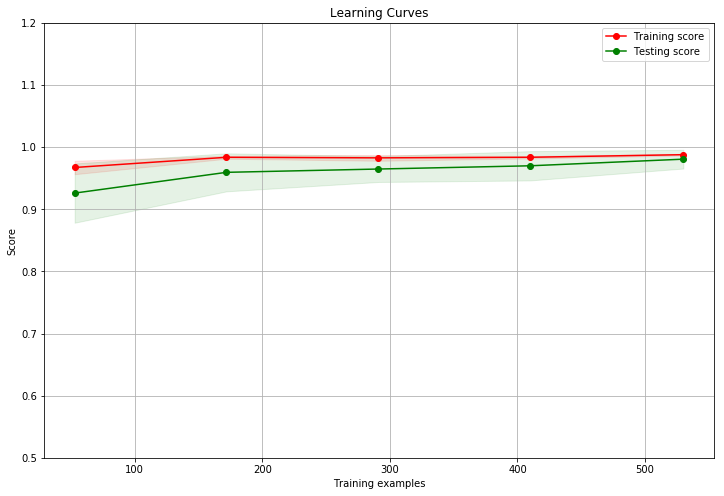

DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=10,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=None,
            splitter='best'): 
CPU times: user 6.8 ms, sys: 0 ns, total: 6.8 ms
Wall time: 6.38 ms
0.9210526315789473



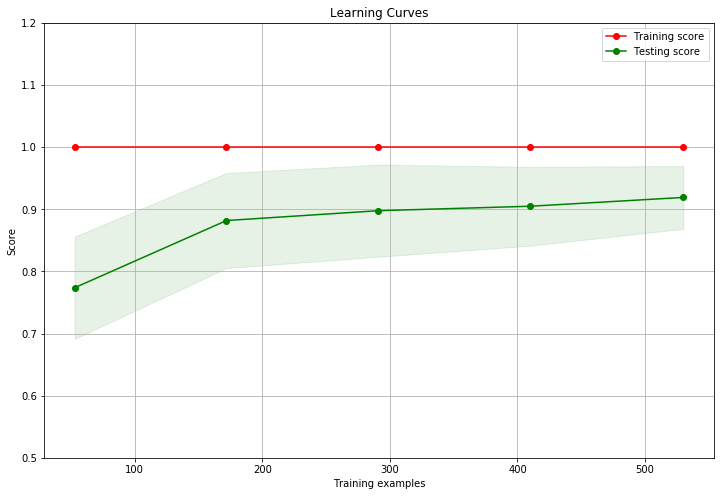

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=10, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators='warn', n_jobs=None,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False): 
CPU times: user 16.5 ms, sys: 291 µs, total: 16.8 ms
Wall time: 16.3 ms
0.9736842105263158



/usr/local/lib/python3.6/dist-packages/sklearn/ensemble/forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


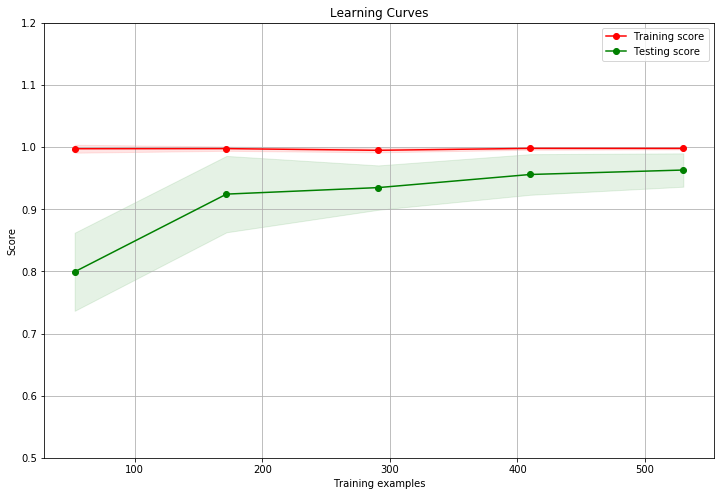

In [25]:
models = [
    LogisticRegression(penalty = 'l2'),
    DecisionTreeClassifier(max_depth=10),
    RandomForestClassifier(max_depth=10)
]

for model in models:
    print(str(model) + ": ")
    %time score = model_train_predict(model, X, y)
    print(str(score) + "\n")
    plt = plot_learning_curve(model, "Learning Curves", X, y, ylim=(0.5, 1.2), cv=15, n_jobs=4)
    plt.show()

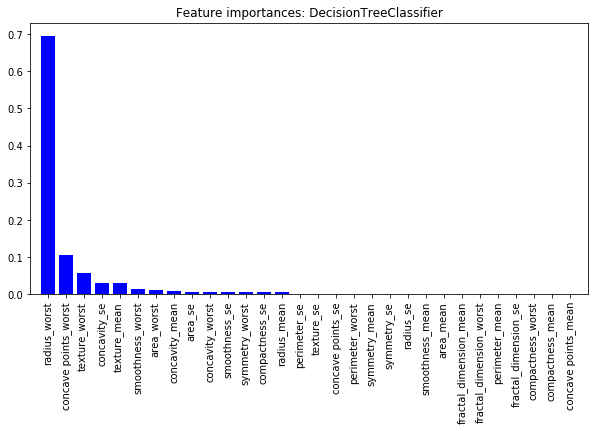

/usr/local/lib/python3.6/dist-packages/sklearn/ensemble/forest.py:246: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


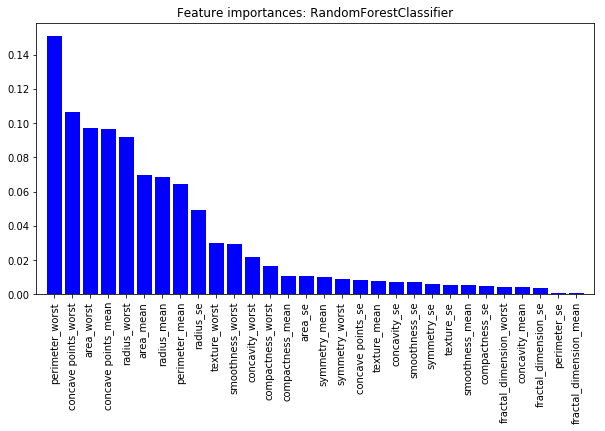

In [26]:
models = [
    DecisionTreeClassifier(max_depth=10),
    RandomForestClassifier(max_depth=10)
]

for model in models:
    model.fit(X, y)
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    plt.figure(figsize=(10, 5))
    plt.title('Feature importances: ' + str(model).split('(')[0])
    plt.bar(range(X.shape[1]), model.feature_importances_[indices],
           color = 'b', align = 'center')
    plt.xticks(range(X.shape[1]), [ feats(df_scaled)[x] for x in indices])
    plt.xticks(rotation=90)
    plt.xlim([-1, X.shape[1]])
    plt.show()

In [27]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
def compute(params):
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    score = accuracy_score(y_val, y_pred)
    #print("Score: %.2f" % score)
    #print(params)
    return (1 - score)

space = {
        'max_depth':  hp.choice('max_depth', range(4,6)),
        'min_child_weight': hp.uniform('min_child_weight', 0, 10),
        'subsample': hp.quniform('subsample', 0.5, 1, 0.05),
        'gamma': hp.quniform('gamma', 0.5, 1, 0.05)
    }

best = fmin(compute, space, algo=tpe.suggest, max_evals=250)
print(best)

{'gamma': 0.9, 'max_depth': 1, 'min_child_weight': 0.13844847311145214, 'subsample': 1.0}


In [28]:
model = xgb.XGBClassifier(**best)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
accuracy_score(y_val, y_pred)

0.9824561403508771

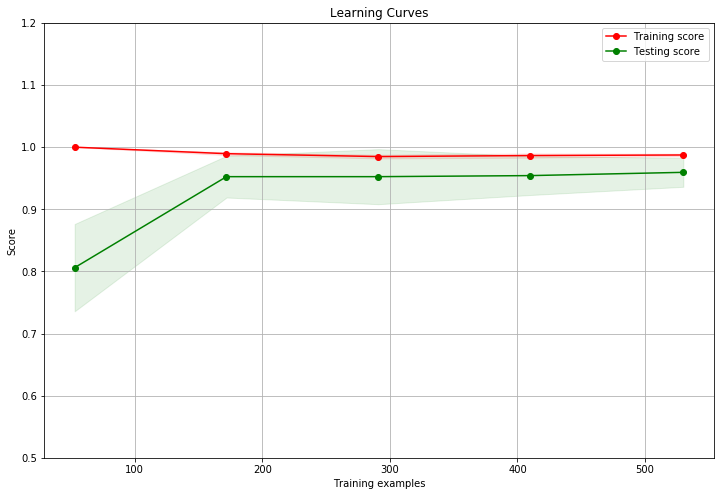

In [29]:
plt = plot_learning_curve(model, "Learning Curves", X, y, ylim=(0.5, 1.2), cv=15, n_jobs=4)
plt.show()

In [30]:
def confusion_matrix(y_val,y_pred):
    confusion_matrix = metrics.confusion_matrix(y_val, y_pred)

    plt.figure(figsize=(5,5))
    ax= plt.subplot()
    sns.heatmap(confusion_matrix, annot=True,fmt='g', ax = ax);
    ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
    ax.set_title('Confusion Matrix'); 
    plt.show()

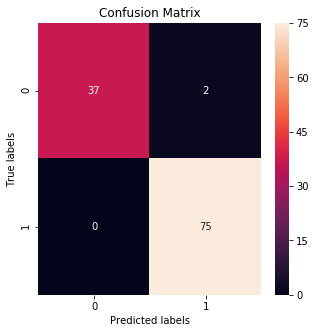

In [31]:
confusion_matrix(y_val, y_pred)

AUC: 0.974


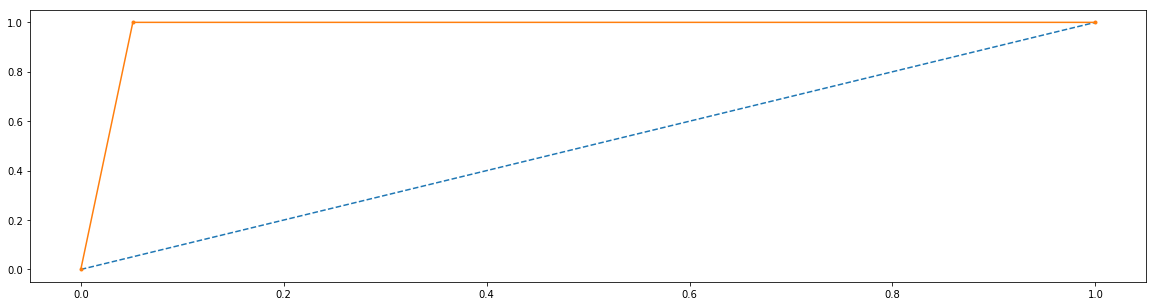

In [32]:
auc = roc_auc_score(y_val, y_pred)
print('AUC: %.3f' % auc)
fpr, tpr, thresholds = roc_curve(y_val, y_pred)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.plot(fpr, tpr, marker='.')
plt.show()

In [33]:
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.fit_transform(X_val)

model_pca = LogisticRegression()
model_pca.fit(X_val_pca, y_val)
model_pca.score(X_val_pca, y_val)

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


0.9736842105263158

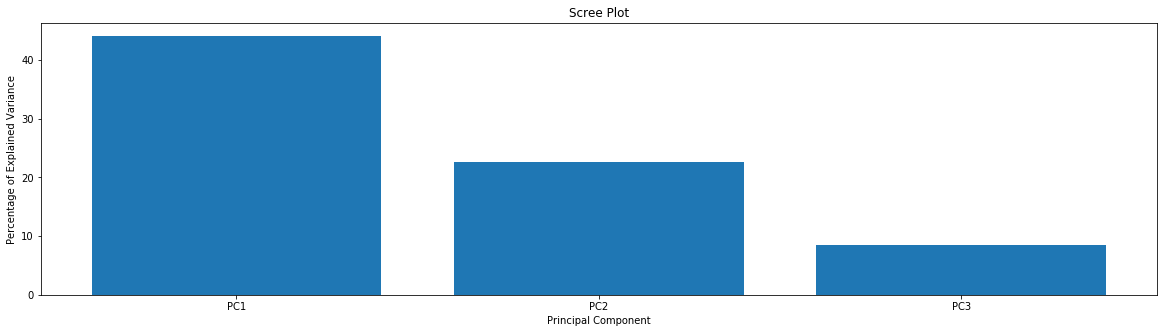

In [34]:
per_var = np.round(pca.explained_variance_ratio_*100, decimals = 1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

plt.bar(x=range(1, len(per_var)+1), height = per_var, tick_label = labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

In [35]:
df_pca = pd.DataFrame(data = X_train_pca, columns = ['PCA_1', 'PCA_2', 'PCA_3'])
df_pca = pd.concat([df_pca, df_scaled['diagnosis']], axis =1)

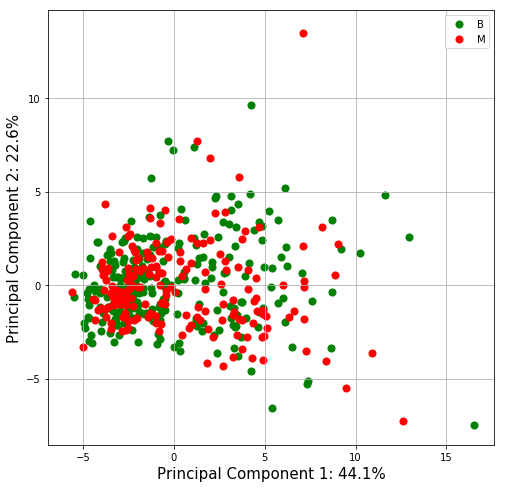

In [36]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('Principal Component 1: {0}%'.format(per_var[0]), fontsize = 15)
ax.set_ylabel('Principal Component 2: {0}%'.format(per_var[1]), fontsize = 15)

targets = ['B', 'M']
colors = ['g', 'r',]
for target, color in zip(targets,colors):
    indicesToKeep = df_pca['diagnosis'] == target
    ax.scatter(df_pca.loc[indicesToKeep, 'PCA_1']
               , df_pca.loc[indicesToKeep, 'PCA_2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

In [37]:
model = SVC(gamma='auto')
model.fit(X_train, y_train)
model.score(X_val, y_val)

1.0

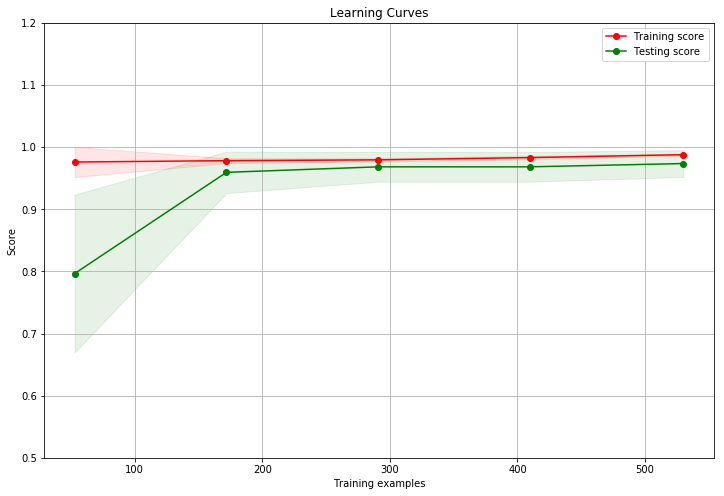

In [38]:
plt = plot_learning_curve(model, "Learning Curves", X, y, ylim=(0.5, 1.2), cv=15, n_jobs=4)
plt.show()

In [39]:
model = LinearSVC(random_state=0, tol=1e-5)
model.fit(X_train, y_train)
model.score(X_val, y_val)

0.9824561403508771

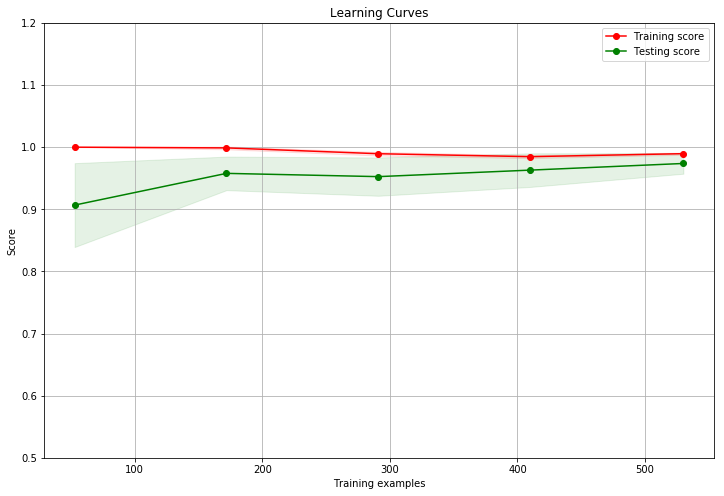

In [40]:
plt = plot_learning_curve(model, "Learning Curves", X, y, ylim=(0.5, 1.2), cv=15, n_jobs=4)
plt.show()

In [41]:
model = linear_model.SGDClassifier(max_iter=1000, tol=1e-3)
model.fit(X_train, y_train)
model.score(X_val, y_val)

0.9912280701754386

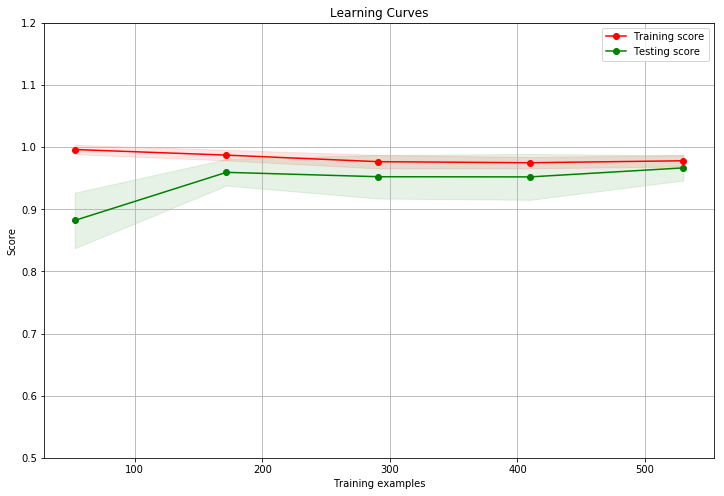

In [42]:
plt = plot_learning_curve(model, "Learning Curves", X, y, ylim=(0.5, 1.2), cv=15, n_jobs=4)
plt.show()

In [43]:
model = GaussianNB()
model.fit(X_train, y_train)
model.score(X_val, y_val)

0.956140350877193

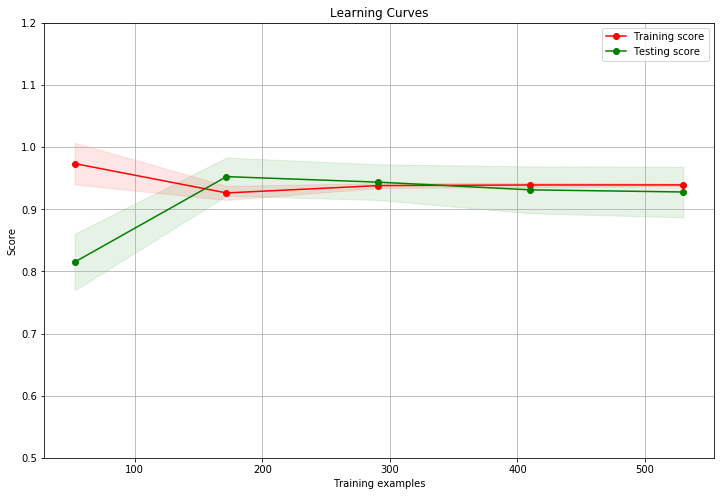

In [44]:
plt = plot_learning_curve(model, "Learning Curves", X, y, ylim=(0.5, 1.2), cv=15, n_jobs=4)
plt.show()